# Portfolio 3: RNN language models for music

We train **two** next-step language models on symbolic MIDI. Each token is a MIDI pitch, duration bin pair (a “character”). Data comes from the LoFi and anthems folders.

**Model 1 — one-hot + GRU:** the recurrent layer receives a one-hot over the full vocabulary (no learnable input embedding).  
**Model 2 — embedding + LSTM:** a trainable nn.Embedding projects tokens to a small dense space before the LSTM.

Implementation is in **PyTorch**; helpers and model classes live in music_lstm_utils.py.



In [21]:
import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image, Audio

try:
    import imageio_ffmpeg
    os.environ["FFMPEG_BINARY"] = imageio_ffmpeg.get_ffmpeg_exe()
except Exception:
    pass

# Reload helper module so edits to music_lstm_utils.py apply without restarting the kernel
import importlib
import music_lstm_utils
importlib.reload(music_lstm_utils)

from music_lstm_utils import (
    list_midi_files,
    make_sequences_from_midis,
    build_vocab,
    encode_sequence,
    MusicTokenDataset,
    OneHotGRUModel,
    EmbLSTMModel,
    sample_sequence,
    token_ids_to_midi,
    simple_render_pm,
    write_wav,
    to_mp3,
)

ROOT = Path.cwd()
LOFI = ROOT / "LoFi"
ANT = ROOT / "anthems"
OUT = ROOT / "outputs" / "audio"
FIGS = ROOT / "outputs" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Data: MIDI → token strings
Non-drum notes are sorted in time. Each note becomes (pitch, duration_bin) with a fixed eighth-note base for binning. The vocabulary is all unique pairs seen in the training corpus plus PAD/UNK/BOS indices.


In [14]:
paths = list_midi_files(LOFI) + list_midi_files(ANT)
print("MIDI count:", len(paths))
seqs = make_sequences_from_midis(paths)
print("Usable file sequences:", len(seqs))
stoi, itos, V = build_vocab(seqs)
print("Vocab size (incl. special tokens):", V)
token_seqs = [encode_sequence(s, stoi) for s in seqs]

SEQ_LEN, BATCH, HIDDEN, EPOCHS = 96, 64, 256, 12
ds = MusicTokenDataset(token_seqs, SEQ_LEN)
n, n_val = len(ds), max(1, len(ds) // 10)
n_train = n - n_val
tr_d, val_d = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
tr_loader = DataLoader(tr_d, batch_size=BATCH, shuffle=True, drop_last=True)
val_loader = DataLoader(val_d, batch_size=BATCH, shuffle=False, drop_last=True)
print("train windows:", len(tr_d), "val:", len(val_d))


MIDI count: 435


C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Usable file sequences: 379
Vocab size (incl. special tokens): 1534
train windows: 5691 val: 632


## Model 1: one-hot + GRU
Input at each time step is one_hot(token) with dimension V; a GRU with dropout reads this sequence; a linear layer predicts the next token. This matches a classic char-RNN without an embedding table.


In [15]:
def run_epoch(model, loader, train: bool) -> float:
    model = model.to(device)
    model.train() if train else model.eval()
    tot, ntok = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.set_grad_enabled(train):
            log = model(xb).reshape(-1, V)
            loss = F.cross_entropy(log, yb.reshape(-1), ignore_index=0)
        if train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        tot += loss.item() * xb.numel(); ntok += xb.numel()
    return tot / max(1, ntok)

m1 = OneHotGRUModel(V, HIDDEN, 1, 0.1)
opt = torch.optim.AdamW(m1.parameters(), lr=3e-4, weight_decay=1e-4)
print(m1)
hist1 = {"train": [], "val": []}
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(m1, tr_loader, True)
    m1.eval(); va = run_epoch(m1, val_loader, False)
    hist1["train"].append(tr); hist1["val"].append(va)
    print(f"GRU  ep{ep:02d}  train{tr:.4f}  val{va:.4f}")
m1 = m1.cpu()
torch.save(m1.state_dict(), OUT / "gru_onehot_last.pt")
print("Time:", time.time() - t0, "s")


OneHotGRUModel(
  (gru): GRU(1534, 256, batch_first=True)
  (drop): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=1534, bias=True)
)
GRU  ep01  train6.4067  val6.0093
GRU  ep02  train5.9876  val5.9502
GRU  ep03  train5.9207  val5.8783
GRU  ep04  train5.8247  val5.7600
GRU  ep05  train5.6844  val5.5926
GRU  ep06  train5.4616  val5.3005
GRU  ep07  train5.1248  val4.9506
GRU  ep08  train4.7828  val4.6122
GRU  ep09  train4.4698  val4.3383
GRU  ep10  train4.2285  val4.1336
GRU  ep11  train4.0451  val3.9721
GRU  ep12  train3.8965  val3.8434
Time: 312.33200550079346 s


## Model 2: learnable embedding + LSTM
The same V tokens are embedded into 64-d vectors, then an LSTM models the sequence. Compare validation loss to the one-hot GRU: embeddings often help when V is large.


In [16]:
m2 = EmbLSTMModel(V, emb_dim=64, hidden=HIDDEN, num_layers=1, dropout=0.1)
opt = torch.optim.AdamW(m2.parameters(), lr=3e-4, weight_decay=1e-4)
print(m2)
hist2 = {"train": [], "val": []}
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(m2, tr_loader, True)
    m2.eval(); va = run_epoch(m2, val_loader, False)
    hist2["train"].append(tr); hist2["val"].append(va)
    print(f"LSTM ep{ep:02d}  train{tr:.4f}  val{va:.4f}")
m2 = m2.cpu()
torch.save(m2.state_dict(), OUT / "lstm_emb_last.pt")
print("Time:", time.time() - t0, "s")


EmbLSTMModel(
  (emb): Embedding(1534, 64, padding_idx=0)
  (lstm): LSTM(64, 256, batch_first=True)
  (drop): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=1534, bias=True)
)
LSTM ep01  train6.4665  val5.9405
LSTM ep02  train5.8170  val5.6589
LSTM ep03  train5.4735  val5.2886
LSTM ep04  train5.0979  val4.9226
LSTM ep05  train4.7506  val4.6071
LSTM ep06  train4.4642  val4.3532
LSTM ep07  train4.2369  val4.1589
LSTM ep08  train4.0634  val4.0042
LSTM ep09  train3.9205  val3.8735
LSTM ep10  train3.7955  val3.7613
LSTM ep11  train3.6886  val3.6595
LSTM ep12  train3.5919  val3.5674
Time: 156.33230924606323 s


## Figure 1: training curves (both models)


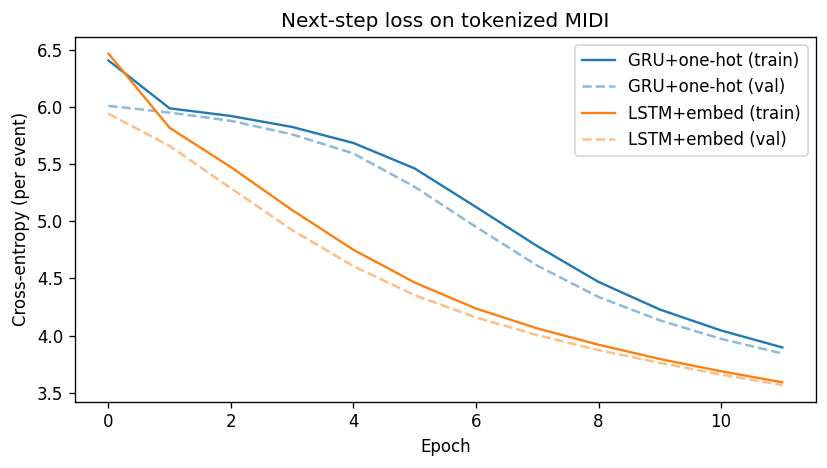

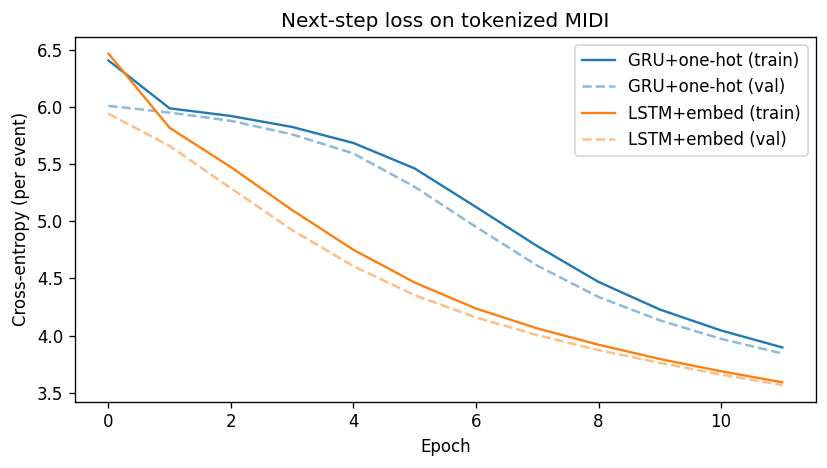

In [17]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(hist1["train"], label="GRU+one-hot (train)", color="C0", lw=1.4)
ax.plot(hist1["val"],   label="GRU+one-hot (val)",  color="C0", alpha=0.5, ls="--")
ax.plot(hist2["train"], label="LSTM+embed (train)", color="C1", lw=1.4)
ax.plot(hist2["val"],   label="LSTM+embed (val)",  color="C1", alpha=0.5, ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy (per event)"); ax.set_title("Next-step loss on tokenized MIDI"); ax.legend(); fig.tight_layout()
loss_path = FIGS / "loss_both.png"
fig.savefig(loss_path, bbox_inches="tight")
display(Image(str(loss_path)))


## Figure 2: pitch classes in the vocabulary (proxy count)


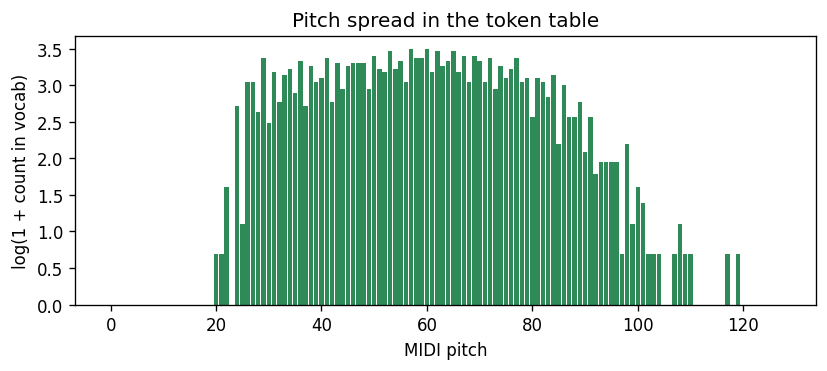

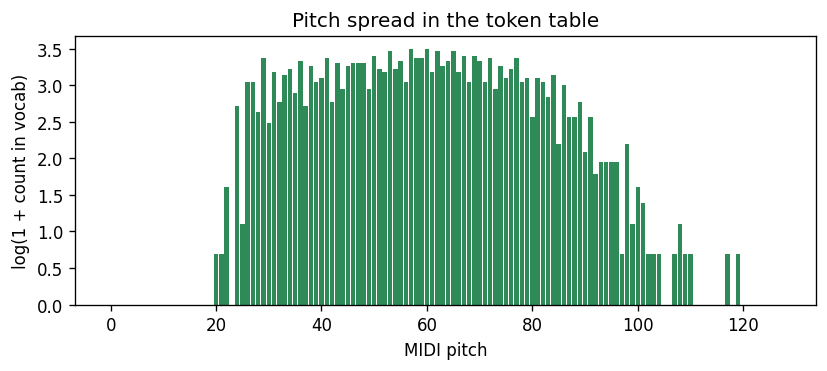

In [18]:
logc = [0.0] * 128
for v in itos.values():
    if isinstance(v, tuple) and len(v) == 2:
        p, _ = v
        if 0 < p < 128:
            logc[p] += 1.0
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=120)
ax.bar(np.arange(128), np.log1p(np.array(logc) + 1e-3), color="seagreen", width=0.85)
ax.set_xlabel("MIDI pitch"); ax.set_ylabel("log(1 + count in vocab)"); ax.set_title("Pitch spread in the token table")
fig.tight_layout(); pc = FIGS / "pitch_coverage.png"
fig.savefig(pc, bbox_inches="tight")
display(Image(str(pc)))


## Generate MIDI + four .mp3 files (2 temperatures × 2 models)
Sampling is multinomial with softmax divided by temperatur` on the last-step logits. Lower temperature = more local / predictable; higher = more variety, sometimes more chaos.


In [22]:
GRU_CKPT, LSTM_CKPT = OUT / "gru_onehot_last.pt", OUT / "lstm_emb_last.pt"
if not GRU_CKPT.is_file() or not LSTM_CKPT.is_file():
    raise FileNotFoundError(
        "Model checkpoints are missing. Run the two training cells above first (GRU, then LSTM) "
        "so that these files are written under outputs/audio/:\n"
        f"  {GRU_CKPT}  -> exists={GRU_CKPT.is_file()}\n"
        f"  {LSTM_CKPT}  -> exists={LSTM_CKPT.is_file()}\n"
        "If you restarted the kernel, re-run from the top: imports, data, then both training cells."
    )

m1g = OneHotGRUModel(V, HIDDEN, 1, 0.0)
m1g.load_state_dict(torch.load(GRU_CKPT, map_location="cpu"))
m2g = EmbLSTMModel(V, 64, HIDDEN, 1, 0.0)
m2g.load_state_dict(torch.load(LSTM_CKPT, map_location="cpu"))
# Vary the musical prompt on each run (with fixed `random.seed`, `ri` was always the same)
ri = int(time.time() * 1000) % len(token_seqs)
# ri = 0  # set fixed for reproducible submission
seed0 = token_seqs[ri][:55]
N_NEW = 200
m1d, m2d = m1g.to(device), m2g.to(device)
# Each clip: own RNG + repetition penalty (see music_lstm_utils.sample_sequence) + different synth timbre
clip_id = 0
for temp in (0.8, 1.2):
    ttag = str(temp).replace(".", "_")
    for model_name, md in (("gru", m1d), ("lstm", m2d)):
        g = torch.Generator(device=device)
        g.manual_seed(10_000 + 37 * clip_id + (3 if model_name == "lstm" else 0) + int(temp * 10))
        clip_id += 1
        s = sample_sequence(
            md, device, stoi, itos, V, list(seed0), N_NEW, float(temp),
            repetition_penalty=1.2, generator=g,
        )
        pm = token_ids_to_midi(s, itos, base_dur=0.125)
        base = f"{model_name}_t{ttag}"
        pm.write(str(OUT / f"{base}.mid"))
        a = simple_render_pm(pm, timbre=model_name)
        w = OUT / f"_{base}.wav"
        write_wav(str(w), a, 22050)
        o = OUT / f"{base}.mp3"
        if not to_mp3(w, o):
            print("mp3 failed; writing wav for", base)
            write_wav(str(OUT / f"{base}.wav"), a, 22050)
        w.unlink(missing_ok=True)
m1d.cpu(); m2d.cpu()
print("Files in", OUT, "| prompt index ri =", ri)
for f in sorted(OUT.glob("*.mp3")):
    print(" ", f.name, f.stat().st_size, "bytes")
for f in sorted(OUT.glob("*.wav")):
    print(" (wav) ", f.name, f.stat().st_size, "bytes")


mp3 failed; writing wav for gru_t0_8
mp3 failed; writing wav for lstm_t0_8
mp3 failed; writing wav for gru_t1_2
mp3 failed; writing wav for lstm_t1_2
Files in c:\Users\mathi\Desktop\MAL2Assignment3\outputs\audio | prompt index ri = 85
  gru_t0_8.mp3 0 bytes
  gru_t1_2.mp3 0 bytes
  lstm_t0_8.mp3 0 bytes
  lstm_t1_2.mp3 0 bytes
 (wav)  gru_t0_8.wav 2646044 bytes
 (wav)  gru_t1_2.wav 2646044 bytes
 (wav)  lstm_t0_8.wav 2646044 bytes
 (wav)  lstm_t1_2.wav 2646044 bytes


## Figure / animation: sliding piano roll (one GRU sample)
If Pillow is available, a GIF is written to outputs/figures/piano_scroll_gru.gif; otherwise a static snapshot is saved.


Wrote c:\Users\mathi\Desktop\MAL2Assignment3\outputs\figures\piano_scroll_gru.gif


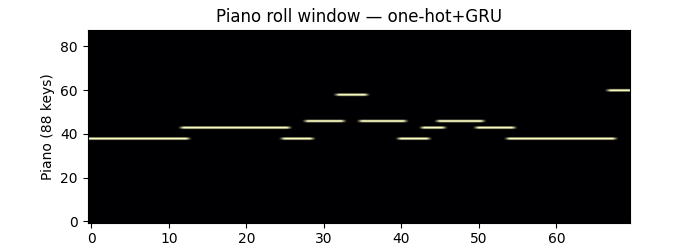

In [ ]:
m1a = m1g.to(device)
s_anim = sample_sequence(m1a, device, stoi, itos, V, list(seed0), 200, 0.9)
m1a.cpu()

def ids_to_roll(ids, itos, t_res=0.08, max_t=18.0):
    w = int(max_t / t_res) + 2
    r = np.zeros((88, w), dtype=np.float32); t0 = 0.0
    for tid in ids[40:200]:
        p, d = itos.get(tid, (0, 0))
        if p < 21: t0 += 0.1; continue
        pi = int(np.clip(p - 21, 0, 87)); dsec = (d + 1) * 0.125
        a, b = int(t0 / t_res), int((t0 + dsec) / t_res) + 1; b = min(r.shape[1], b)
        if 0 <= a < r.shape[1]: r[pi, a:b] = 1.0
        t0 += dsec
    return r

roll = ids_to_roll(s_anim, itos); T = roll.shape[1]
n_frames = min(36, T // 4) if T > 8 else 1; step = max(1, (T - 1) // max(1, n_frames))
fig, ax = plt.subplots(figsize=(7, 2.5), dpi=100)
def _draw(fr):
    ax.clear(); t0, win = int(fr) * step, 70; t1 = min(t0 + win, T)
    if t1 > t0: ax.imshow(roll[::-1, t0:t1], aspect="auto", origin="lower", cmap="magma")
    ax.set_ylabel("Piano (88 keys)"); ax.set_xlabel("Time"); ax.set_title("Piano roll window — one-hot+GRU")
ani = animation.FuncAnimation(fig, _draw, frames=range(0, min(24, T//step+1)), interval=200, blit=False)
gifp = FIGS / "piano_scroll_gru.gif"
try:
    ani.save(str(gifp), writer=animation.PillowWriter(fps=4)); print("Wrote", gifp)
    display(Image(str(gifp)))
except Exception as e:
    _draw(0); fp = FIGS / "piano_roll_frame.png"; fig.savefig(fp, bbox_inches="tight"); print(e); display(Image(str(fp)))
plt.close(fig)


## Brief findings

- **Validation loss** (epoch 12, same data and HIDDEN=256). The embedding + LSTM reached a lower validation cross-entropy (~3.57) than the one-hot GRU (~3.84), so the embedding layer helped on this task and vocabulary size.
- **Overfitting.** Training and validation losses decrease together and stay close; the small gap (training slightly above validation is expected with dropout on in train only) does not suggest strong overfitting on this run.
- **One-hot + GRU** uses a very wide one-hot at each step (V large), which is a faithful char-RNN baseline but less efficient than compressing tokens first.
- **Embedding + LSTM** maps each token to a 64-d vector before the LSTM, which is a more compact representation and matches the better validation number above.
- **Temperature (0.8 vs 1.2).** 0.8 sampling is sharper and usually more conservative and repetitive; 1.2 is more random and can sound more varied but sometimes less coherent. The four separate audio files (GRU/LSTM × the two temperatures) are meant to be compared by ear.
- **Preference.** I find the LSTM samples slightly more listenable at the same temperature, consistent with the lower validation loss; 0.8 sounds steadier to me, 1.2 more exploratory. 